# Analiza Billboard singlov

V tem zvezku analiziram podatke iz treh CSV datotek, ki so v isti mapi kot ta zvezek:

- `singles.csv` – po ena vrstica na pesem na leto (stolpci npr.: `leto`, `mesto`, `naslov`, `avtorji`)
- `razsirjeno.csv` – po ena vrstica na kombinacijo *pesem–izvajalec* (npr.: `leto`, `mesto`, `naslov`, `izvajalec`)
- `izvajalci_drzava.csv` – podatki o izvajalcih (npr.: `izvajalec`, `drzava`, `leto_rojstva`)

V tem zvezku:
1. pogledam koliko avtorjev se pojavlja na leto in koliko na pesem
2. poiščem pesmi, ki se pojavljajo v več letih,
3. razvrstim izvajalce po številu pojavljanj,
4. pogledam zastopanost držav po letih,
5. poiščem najstarejše in najmlajše izvajalce ter analiziram, kako se povprečna starost izvajalcev spreminja skozi leta,
6. pogledam, kako se skozi leta spreminjajo t. i. "mega-hit" izvajalci (zelo pogosti v enem letu).



### Priprava
Najprej si pripravim okolje za delo. Uvozim csv datoteke in ustvarim še tabelo ki vsebuje leto, skladbo, avtorja in podatke o avtorju.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', None)

singli = pd.read_csv('singles.csv')
razsirjeno = pd.read_csv('razsirjeno.csv')
izvajalci = pd.read_csv('izvajalci_drzava.csv')
izvajalci['leto_rojstva'] = izvajalci['leto_rojstva'].astype('Int64')

zdruzeno = razsirjeno.merge(izvajalci, on='izvajalec', how='left')


## 1. Število avtorjev na lestvici 
Najprej me zanima koliko ustvarjalcev se pojavi na lestvici skozi leta.

In [4]:
stevilo_na_leto = zdruzeno.groupby('leto').size().reset_index(name='ustvarjalcev')
stevilo_na_leto.sort_values(by='ustvarjalcev', ascending=False)

,leto,ustvarjalcev
3,2018,161
2,2017,157
0,2015,152
6,2021,150
5,2020,149
1,2016,148
7,2022,147
4,2019,146
8,2023,137
9,2024,130


Vidim, da se v zadnjih letih na lestvici pojavi manj avtorjev (skupine tu upoštevam kot posameznega avtorja za več izvajalcev štejejo "colaborations") to je lahko posledica večih avtorjev, ki se pojavijo večkrat, ali pa manj skladb z večimi avtorji. To bom preverila v naslednji vrstici.

In [5]:
singli['stevilo_izvajalcev'] = (
    singli['avtorji']
        .fillna('')
        .apply(lambda x: 0 if x == '' else len([a for a in str(x).split('|') if a.strip() != '']))
)

def kategorija_izvajalcev(n):
    if n <= 2:
        return str(n)
    else:
        return '3+'

singli['kategorija_izvajalcev'] = singli['stevilo_izvajalcev'].apply(kategorija_izvajalcev)
porazdelitev_kategorije = (
    singli
    .groupby(['leto', 'kategorija_izvajalcev'])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

porazdelitev_kategorije


kategorija_izvajalcev,1,2,3+
leto,,,
2015,65,23,12
2016,63,30,7
2017,56,34,10
2018,57,31,12
2019,64,27,9
2020,57,38,5
2021,61,29,10
2022,67,25,8
2023,67,29,4


<Axes: xlabel='leto'>

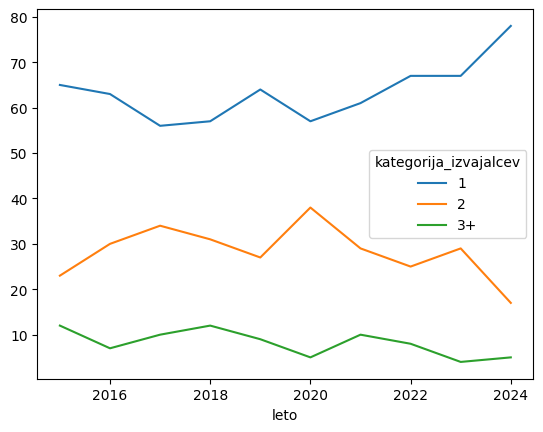

In [6]:
porazdelitev_kategorije.plot()

### Ugotovitve - število avtorjev na lestvici
Opazim, da je vedno več posamičnih avtorjev in vedno manj sodelovanj. Kar potrdi moje predvidevanje da je manj skladb z večimi avtorji. Posebaj izstopa leto 2024 s kar 78 pesmimi z enim izvajalcem kar je 11 več kot katerokoli drugo leto.

## 2. Pesmi, ki se pojavljajo v več letih

Najprej pogledam, katere pesmi se na letnih Billboard lestvicah pojavijo v več različnih letih. To so običajno sezonske uspešnice (npr. božične pesmi) ali pesmi, ki imajo zelo dolgo "življenjsko dobo" na lestvici.

Spodaj poiščem pesmi ki se na lestvici pojavijo vsaj dvakrat.


In [7]:
pojavitve = singli.groupby(['naslov', 'avtorji']).size().reset_index(name='stevilo_pojavitev')
pesmi_vec_let = pojavitve[pojavitve['stevilo_pojavitev'] > 1]
pesmi_vec_let = pesmi_vec_let.sort_values(by='stevilo_pojavitev', ascending=False)

print(f"Skupno pesmi, ki se pojavijo v več letih: {len(pesmi_vec_let)}")

pesmi_vec_let.head(10)


Skupno pesmi, ki se pojavijo v več letih: 104


,naslov,avtorji,stevilo_pojavitev
26,All I Want for Christmas Is You,Mariah Carey,5
615,Rockin' Around the Christmas Tree,Brenda Lee,4
387,Jingle Bell Rock,Bobby Helms,3
12,A Holly Jolly Christmas,Burl Ives,3
40,As It Was,Harry Styles,2
52,Bad Guy,Billie Eilish,2
7,679,Fetty Wap | Remy Boyz,2
1,1-800-273-8255,Logic | Alessia Cara | Khalid,2
79,Believer,Imagine Dragons,2
83,Better Now,Post Malone,2


### Ugotovitve - pesmi v več letih

V tej analizi vidim, katere pesmi imajo daljšo prisotnost na lestvici. Po pričakovanju prevladujejo sezonske pesmi - Božične uspešnice. Z izjemo božičnih uspešnic se nobena skladba ne pojavi več kot dvkrat.

## 3. Izvajalci po številu pojavljanj na lestvici

Zdaj pogledam, kateri izvajalci se najpogosteje pojavljajo na letnih Billboard lestvicah. Ker je v tabeli `razsirjeno` po ena vrstica za vsako kombinacijo pesem–izvajalec, vsaka vrstica predstavlja eno pojavljanje izvajalca.

Spodaj tabela izvajalcev po številu pojavitev.

In [8]:
# Število pojavljanj izvajalcev (urejena tabela)
pojavitve_izvajalcev = razsirjeno.groupby('izvajalec').size().sort_values(ascending=False)
tabela_pojavitev_izvajalcev = pojavitve_izvajalcev.reset_index(name='stevilo_pojavitev')
tabela_pojavitev_izvajalcev.head(20)


,izvajalec,stevilo_pojavitev
0,Drake,52
1,Justin Bieber,25
2,Ariana Grande,24
3,The Weeknd,24
4,Taylor Swift,22
5,Morgan Wallen,21
6,Nicki Minaj,21
7,Post Malone,21
8,Cardi B,19
9,Doja Cat,19


### Ugotovitve - izvajalci po številu pojavljanj

Iz sortirane tabele vidim, kateri izvajalci imajo v opazovanem obdobju največ pojavljanj na lestvici. Opazim da je Drake dominiral na glasbeni sceni v zadnjih 10 letih, saj ima 2x toliko pojavitev kot Justin Bieber na 2. mestu.

## 4. Države izvajalcev po letih

Zdaj me zanima, iz katerih držav prihajajo izvajalci na lestvici in kako se to spreminja skozi leta. Za to uporabim že pripravljeno združeno tabelo `zdruzeno`.

Spodaj ugotovim koliko pojavitev ima posamezna država v celotnem obdobju. Za najboljših 5 držav pa ugotvim delež za vsako leto in pogledam kako se spreminja skozi čas.

In [9]:
skupaj_po_drzavi = zdruzeno['drzava'].value_counts()
skupaj_po_drzavi.head(10)

drzava
United States     1038
Canada             133
United Kingdom     100
Puerto Rico         24
France              14
Colombia            13
Nigeria              9
Mexico               6
Germany              6
Denmark              5
Name: count, dtype: int64

<Axes: title={'center': 'Porazdelitev držav izvajalcev'}>

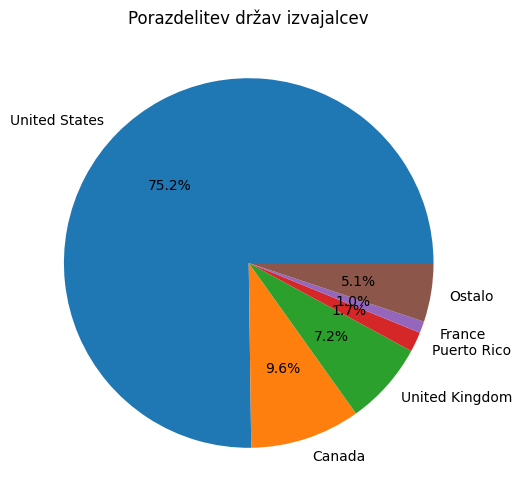

In [10]:
top5 = skupaj_po_drzavi.head(5)
ostalo = skupaj_po_drzavi.iloc[5:].sum()
podatki = top5.copy()
podatki['Ostalo'] = ostalo


podatki.plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title="Porazdelitev držav izvajalcev", ylabel="")



In [11]:
top5 = skupaj_po_drzavi.head(5).index

pivot = zdruzeno[zdruzeno['drzava'].isin(top5)].pivot_table(
    index='leto',
    columns='drzava',
    values='naslov',  
    aggfunc='count',
    fill_value=0
)

pivot = pivot.reset_index()
pivot = pivot.merge(stevilo_na_leto[['leto', 'ustvarjalcev']], on='leto')
stolpci_drzav = [c for c in pivot.columns if c not in ('leto', 'ustvarjalcev')]
pivot_procenti = pivot[['leto'] + stolpci_drzav].copy()
pivot_procenti



,leto,Canada,France,Puerto Rico,United Kingdom,United States
0,2015,14,3,0,16,104
1,2016,26,4,0,13,91
2,2017,14,4,1,13,115
3,2018,14,1,4,12,114
4,2019,8,1,4,8,115
5,2020,15,0,0,7,113
6,2021,19,0,3,4,106
7,2022,10,0,9,15,82
8,2023,7,1,2,7,95
9,2024,6,0,1,5,103


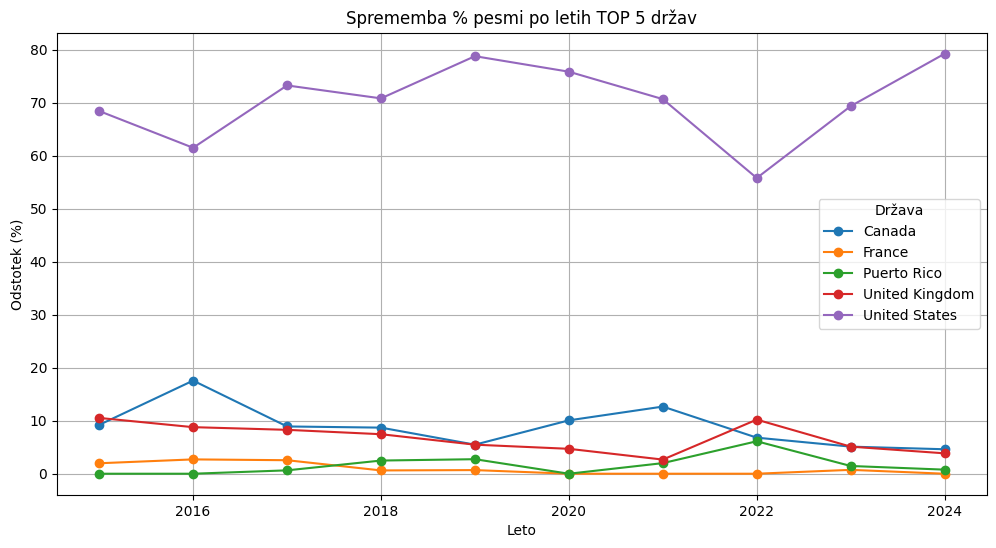

In [12]:
for c in stolpci_drzav:
    pivot_procenti[c] = pivot[c] / pivot['ustvarjalcev'] * 100
pivot_procenti = pivot_procenti.set_index('leto')

plt.figure(figsize=(12, 6))

for drzava in pivot_procenti.columns:
    plt.plot(pivot_procenti.index, pivot_procenti[drzava], marker='o', label=drzava)

plt.title("Sprememba % pesmi po letih TOP 5 držav")
plt.xlabel("Leto")
plt.ylabel("Odstotek (%)")
plt.legend(title="Država")
plt.grid(True)
plt.show()


### Ugotovitve - države izvajalcev

Na lestvici prevladujejo Ameriški ustvarjalci. Sledita ji angleško govoreči Kanada in Združeno kraljestvo kar je pričakovano za revijo iz ZDA. Manjši dele ustvarjalcev iz ZDA opazen le v letu 2022:

## 5.Starost izvajalcev

Ker imam v tabeli `izvajalci_drzava` tudi leto rojstva izvajalcev, lahko izračunam, koliko so bili izvajalci stari v posameznem letu, ko so bili na lestvici.

- v združeni tabeli `zdruzeno` izračunam novo spremenljivko `starost = leto - leto_rojstva`,
- prikažem najstarejše in najmlajše izvajalce
- po letih izračunam povprečno starost,
- rezultate prikažem v tabeli in na črtnem grafu.


In [13]:
zdruzeno['starost'] = zdruzeno['leto'] - zdruzeno['leto_rojstva']
zdruzeno.sort_values(by='starost', ascending=True).head(10)

,leto,mesto,naslov,izvajalec,drzava,leto_rojstva,starost
9,2015,8,Watch Me,Silentó,United States,1998,17
658,2019,28,Ransom,Lil Tecca,United States,2002,17
751,2019,92,Shotta Flow,Nle Choppa,United States,2002,17
206,2016,38,"I Hate U, I Love U",Olivia O'Brien,United States,1999,17
53,2015,36,Stitches,Shawn Mendes,Canada,1998,17
623,2019,4,Bad Guy,Billie Eilish,United States,2001,18
925,2021,8,Drivers License,Olivia Rodrigo,United States,2003,18
718,2019,67,When the Party's Over,Billie Eilish,United States,2001,18
163,2016,8,Don't Let Me Down,Daya,United States,1998,18
809,2020,35,Savage Love (Laxed – Siren Beat),Jawsh 685,New Zealand,2002,18


In [14]:
zdruzeno.sort_values(by='starost', ascending=True).dropna().tail(10)

,leto,mesto,naslov,izvajalec,drzava,leto_rojstva,starost
1053,2021,92,Rockin' Around the Christmas Tree,Brenda Lee,United States,1944,77
1180,2022,80,Rockin' Around the Christmas Tree,Brenda Lee,United States,1944,78
1290,2023,60,Rockin' Around the Christmas Tree,Brenda Lee,United States,1944,79
1424,2024,59,Rockin' Around the Christmas Tree,Brenda Lee,United States,1944,80
1188,2022,86,Jingle Bell Rock,Bobby Helms,United States,1933,89
1299,2023,68,Jingle Bell Rock,Bobby Helms,United States,1933,90
1436,2024,68,Jingle Bell Rock,Bobby Helms,United States,1933,91
1192,2022,89,A Holly Jolly Christmas,Burl Ives,United States,1909,113
1304,2023,71,A Holly Jolly Christmas,Burl Ives,United States,1909,114
1469,2024,94,A Holly Jolly Christmas,Burl Ives,United States,1909,115


Vidim da je kar 5 izvajalcev prišlo na lestvico pri 17 letih, kar je tudi najmanjša starost. Najstarejši so avtorji Božičnih uspešnic, ki so bile napisane dolgo nazaj in se vračajo na lestvico, čeprav so avtorji že pokojni.

In [15]:

povprecna_starost_po_letih = zdruzeno.groupby('leto')['starost'].mean()
povprecna_starost_po_letih.round(2)



leto
2015    29.58
2016    27.45
2017     28.1
2018    28.23
2019    27.76
2020    27.99
2021    29.46
2022    32.57
2023    32.37
2024    33.06
Name: starost, dtype: Float64

<Axes: title={'center': 'Povprečna starost izvajalcev na letni Billboard lestvici'}, xlabel='Leto', ylabel='Povprečna starost izvajalcev'>

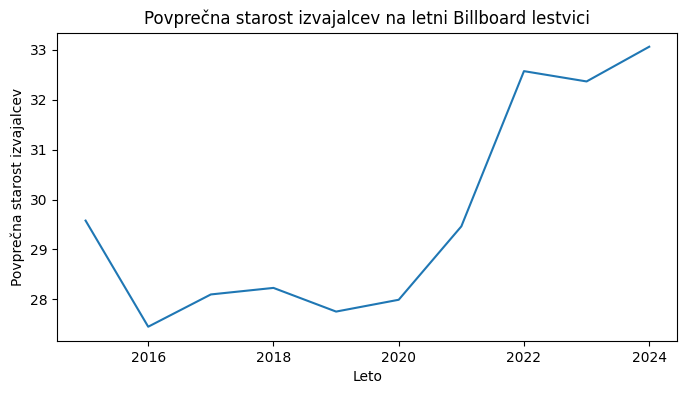

In [16]:
povprecna_starost_po_letih.plot(figsize=(8, 4), xlabel='Leto', ylabel='Povprečna starost izvajalcev', title='Povprečna starost izvajalcev na letni Billboard lestvici')

### Ugotovitve - povprečna starost

Na grafu vidim da se povprečna starost izvajalcev v zadnjih letih viša. To lahko pripišem pojavitvi božičnih uspešnic, ki so na lestvici v zadnjih 3 letih, saj močno dvignejo povprečno starost.

## 6. "Mega-hit" izvajalci - zelo pogosti v enem letu

Na koncu pogledam še t. i. "mega-hit" izvajalce – to so izvajalci, ki se v enem letu pojavijo zelo velikokrat. Za to si izberem prag 5 pojavitev v enem letu in pogledam, koliko takih izvajalcev je v posameznem letu in kdo so.

Kaj naredim v spodnjih celicah:
- v tabeli `razsirjeno` preštejem pojavljanja po `(leto, izvajalec)`,
- izberem pare, kjer je število pojavljanj vsaj 5,
- prikažem tabelo mega-hit izvajalcev,
- izračunam, koliko mega-hit izvajalcev je v posameznem letu in narišem graf,


In [17]:
pojavitve_izvajalec_leto = razsirjeno.groupby(['leto', 'izvajalec']).size().reset_index(name='stevilo')
mega_izvajalci = pojavitve_izvajalec_leto[pojavitve_izvajalec_leto['stevilo'] >= 5]
stevilo_mega_izvajalcev = mega_izvajalci.groupby('izvajalec')
print(f'Skupno mega-hit pojavitev (leto, izvajalec) z vsaj 5 pojavitvami: {len(mega_izvajalci)}')
print(f'skupno mega-hit izvajalcev: {len(stevilo_mega_izvajalcev)}')
mega_izvajalci.sort_values(by='stevilo', ascending=False).head(10)


Skupno mega-hit pojavitev (leto, izvajalec) z vsaj 5 pojavitvami: 30
skupno mega-hit izvajalcev: 19


,leto,izvajalec,stevilo
123,2016,Drake,8
336,2018,Drake,8
324,2018,Cardi B,8
860,2023,Morgan Wallen,8
703,2022,Bad Bunny,7
721,2022,Doja Cat,7
578,2020,Roddy Ricch,6
630,2021,Doja Cat,6
632,2021,Drake,6
649,2021,Justin Bieber,6


Število mega-hit izvajalcev po letih:

In [18]:
stevilo_mega_po_letih = mega_izvajalci.groupby('leto')['izvajalec'].nunique()
stevilo_mega_po_letih


leto
2015    4
2016    3
2017    1
2018    2
2019    4
2020    5
2021    4
2022    3
2023    2
2024    2
Name: izvajalec, dtype: int64

<Axes: title={'center': 'Stevilo mega-hit izvajalcev po letih (prag = 5 pojavljanj v letu'}, xlabel='leto', ylabel='Število mega-hit izvajalcev'>

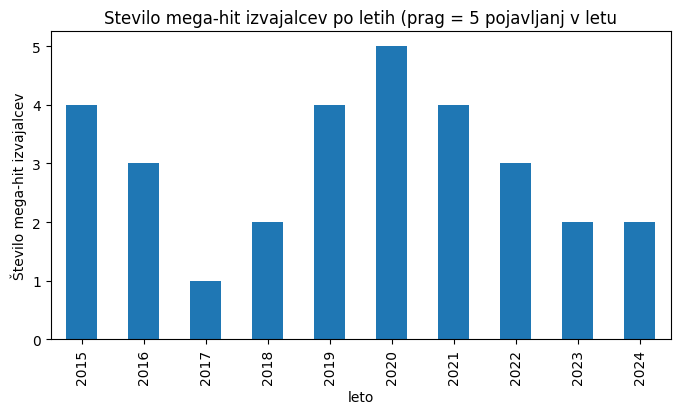

In [19]:
stevilo_mega_po_letih.plot(kind='bar', figsize=(8, 4), ylabel='Število mega-hit izvajalcev', title='Stevilo mega-hit izvajalcev po letih (prag = 5 pojavljanj v letu')

### Ugotovitve - mega-hit izvajalci

Število mega-hit izvajalcev po letih mi pokaže, ali so določena leta bolj "koncentrirana" na nekaj imen. Opazim da ima 2017 le enega mega-hit izvajalca prav tako pa sem v prvi analizi ugotovila, da je na 2. mestu po številu izvajalcev za letom 2018, ki ima 2 mega-hit izvajalca. Na podlagi teh podatkov ocenjujem da sta imeli leti 2017 in 2018 najbolj raznoliko glasbeno sceno.

## Zaključek

Na podlagi izvedene analize lahko ugotovimo, da je glasbena scena izjemno dinamična in pod vplivom številnih dejavnikov. Podatki kažejo, da se obdobja, v katerih prevladuje le nekaj izstopajočih ustvarjalcev, izmenjujejo z leti večje raznolikosti, ko se na lestvice prebije širši krog glasbenikov. Posebej zanimiva je ponovna rast priljubljenosti sezonskih pesmi, kar potrjuje, da se poslušalci radi vračamo k glasbi, ki vzbuja nostalgijo in prijetna čustva. Čeprav analiza vključuje določene omejitve saj analiziram le na podlagi Billboard revije, vseeno ponuja dober vpogled v trende zadnjih let ter odpira prostor za nadaljnje raziskovanje, na primer po žanrih, sodelovanjih ali vplivu digitalnih platform.